In [1]:
import pandas as pd
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
train = pd.read_csv("../data/train.csv")
validation = pd.read_csv("../data/validation.csv")
test = pd.read_csv("../data/test.csv")

print("Training rows:", len(train))
print("Validation rows:", len(validation))
print("Test rows:", len(test))

Training rows: 4565
Validation rows: 978
Test rows: 979


In [4]:
id="q7m2kx"
final_train = pd.concat([train, validation], ignore_index=True)

print("Final training rows:", len(final_train))
print("Test rows:", len(test))

Final training rows: 5543
Test rows: 979


In [5]:
features = [
    "Vol",
    "lag_15",
    "lag_30",
    "lag_60",
    "lag_120",
    "lag_1day",
    "hour",
    "day_of_week",
    "SegmentID",
    "Direction"
]

target = "target_15min"

X_final = final_train[features]
y_final = final_train[target]

X_test = test[features]
y_test = test[target]

print("Final training features:", X_final.shape)
print("Test features:", X_test.shape)

Final training features: (5543, 10)
Test features: (979, 10)


In [6]:
numerical_features = [
    "Vol",
    "lag_15",
    "lag_30",
    "lag_60",
    "lag_120",
    "lag_1day",
    "hour",
    "day_of_week"
]

categorical_features = [
    "SegmentID",
    "Direction"
]

In [7]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [8]:
final_rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "regressor",
            RandomForestRegressor(
                n_estimators=200,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [9]:
final_rf_model.fit(X_final, y_final)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['Vol','lag_15','lag_30',...,'day_of_week','SegmentID','Direction']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columns

In [10]:
y_test_pred = final_rf_model.predict(X_test)

print("Test predictions created:", len(y_test_pred))

Test predictions created: 979


In [11]:
test_mae = mean_absolute_error(y_test, y_test_pred)

print("Random Forest Test MAE:", test_mae)

Random Forest Test MAE: 9.994034729315628


In [12]:
test_rmse = np.sqrt(
    mean_squared_error(y_test, y_test_pred)
)

print("Random Forest Test RMSE:", test_rmse)

Random Forest Test RMSE: 13.67920941332673


In [13]:
test_results = test[["SegmentID", "Direction"]].copy()

test_results["Actual"] = y_test.values
test_results["Predicted"] = y_test_pred

test_results["Absolute_Error"] = (
    test_results["Actual"] - test_results["Predicted"]
).abs()

test_results


,SegmentID,Direction,Actual,Predicted,Absolute_Error
0,177615,WB,100.0,100.055,0.055
1,191114,NB,232.0,208.445,23.555
2,177615,WB,108.0,96.340,11.660
3,191114,NB,223.0,215.715,7.285
4,157501,SB,232.0,233.935,1.935
...,...,...,...,...,...
974,177615,WB,94.0,98.230,4.230
975,177615,EB,73.0,91.135,18.135
976,191114,NB,254.0,252.775,1.225
977,177615,EB,80.0,86.295,6.295


In [14]:
final_segment_metrics = (
    test_results
    .groupby(["SegmentID", "Direction"])
    .agg(
        MAE=("Absolute_Error", "mean"),
        RMSE=("Absolute_Error", lambda x: np.sqrt(np.mean(x**2)))
    )
    .reset_index()
)

final_segment_metrics

,SegmentID,Direction,MAE,RMSE
0,157501,SB,12.770185,17.461320
1,177615,EB,8.446837,11.275240
2,177615,WB,7.768902,10.518993
3,191114,NB,11.021959,14.390230


In [17]:
plot_data = test.copy()

plot_data["Actual"] = y_test.values
plot_data["Predicted"] = y_test_pred

plot_data["timestamp"] = pd.to_datetime(plot_data["timestamp"])

plot_data = plot_data.sort_values("timestamp")

plot_data.head()

,RequestID,Boro,Yr,M,D,HH,MM,Vol,SegmentID,WktGeom,...,lag_15,lag_30,lag_60,lag_120,target_15min,hour,day_of_week,lag_1day,Actual,Predicted
0,32970,Queens,2021,3,19,17,45,106,177615,POINT (1028931.8143046284 215115.26618027306),...,103.0,111.0,126.0,116.0,100.0,17,4,88.0,100.0,100.055
1,32970,Brooklyn,2021,3,19,17,45,205,191114,POINT (988207.4245194928 151130.52481856258),...,255.0,246.0,245.0,269.0,232.0,17,4,170.0,232.0,208.445
2,32970,Queens,2021,3,19,18,0,100,177615,POINT (1028931.8143046284 215115.26618027306),...,106.0,103.0,111.0,101.0,108.0,18,4,70.0,108.0,96.340
3,32970,Brooklyn,2021,3,19,18,0,232,191114,POINT (988207.4245194928 151130.52481856258),...,205.0,255.0,228.0,282.0,223.0,18,4,183.0,223.0,215.715
4,32970,Brooklyn,2021,3,19,18,0,231,157501,POINT (988148.6889210109 151103.24158873298),...,264.0,265.0,267.0,255.0,232.0,18,4,238.0,232.0,233.935


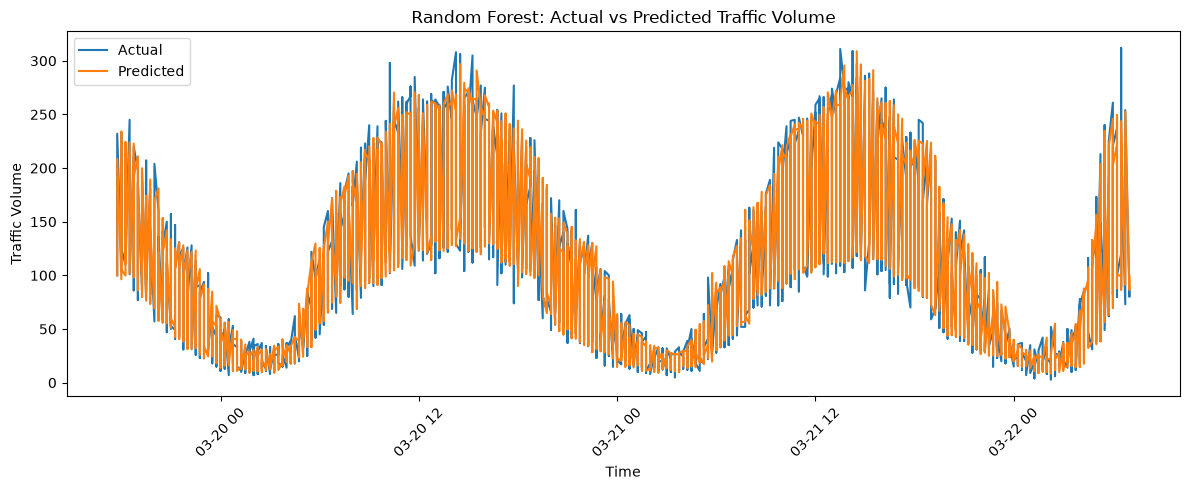

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    plot_data["timestamp"],
    plot_data["Actual"],
    label="Actual"
)

plt.plot(
    plot_data["timestamp"],
    plot_data["Predicted"],
    label="Predicted"
)

plt.xlabel("Time")
plt.ylabel("Traffic Volume")
plt.title("Random Forest: Actual vs Predicted Traffic Volume")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [19]:
segment_pairs = (
    test[["SegmentID", "Direction"]]
    .drop_duplicates()
    .sort_values(["SegmentID", "Direction"])
)

segment_pairs

,SegmentID,Direction
4,157501,SB
5,177615,EB
0,177615,WB
1,191114,NB


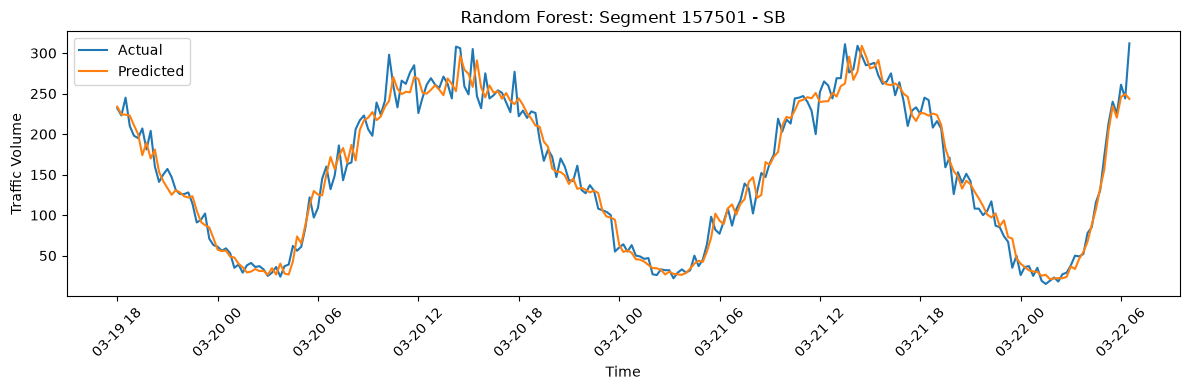

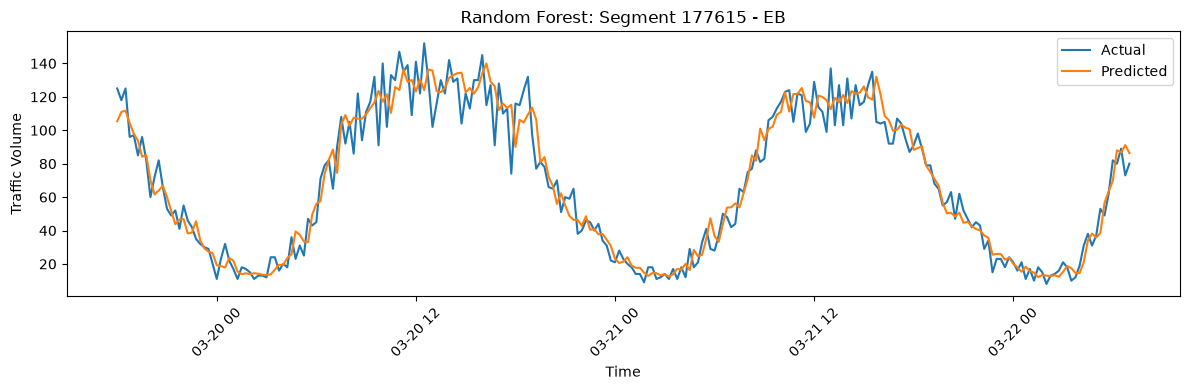

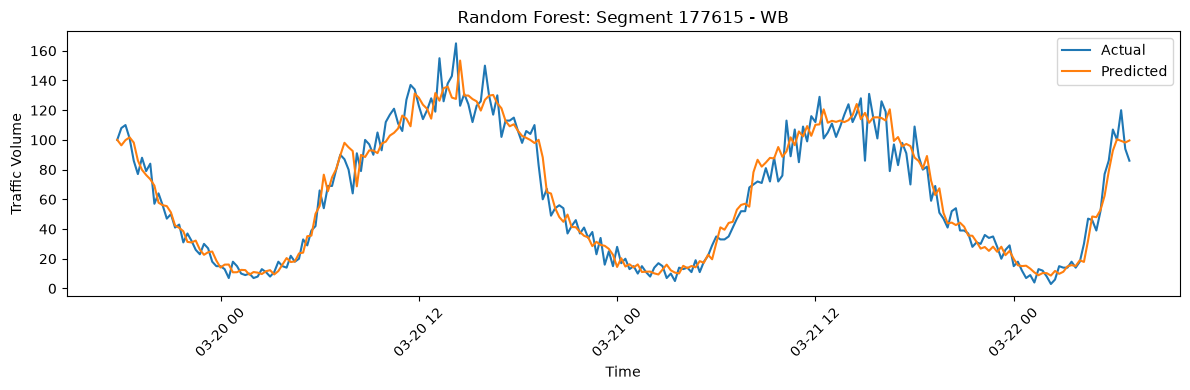

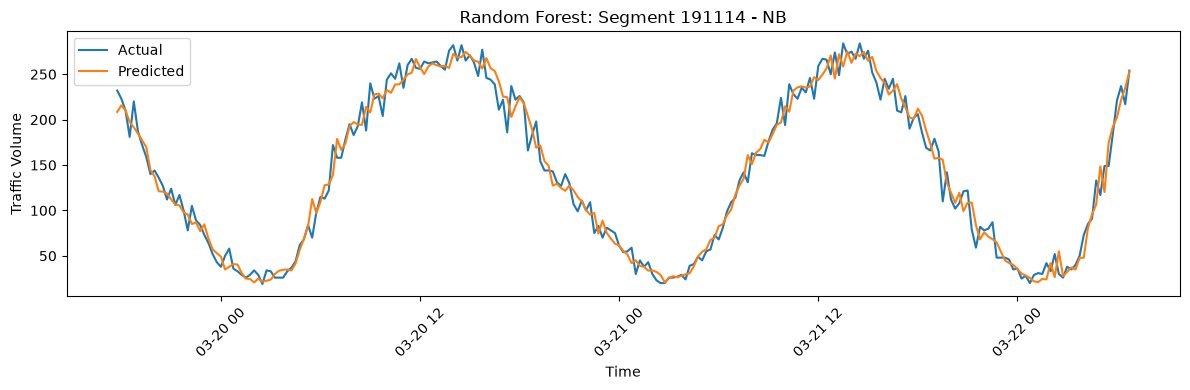

In [20]:
import matplotlib.pyplot as plt

for _, row in segment_pairs.iterrows():
    segment_id = row["SegmentID"]
    direction = row["Direction"]

    subset = plot_data[
        (plot_data["SegmentID"] == segment_id) &
        (plot_data["Direction"] == direction)
    ].sort_values("timestamp")

    plt.figure(figsize=(12, 4))

    plt.plot(
        subset["timestamp"],
        subset["Actual"],
        label="Actual"
    )

    plt.plot(
        subset["timestamp"],
        subset["Predicted"],
        label="Predicted"
    )

    plt.xlabel("Time")
    plt.ylabel("Traffic Volume")
    plt.title(
        f"Random Forest: Segment {segment_id} - {direction}"
    )
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()

    plt.show()